# WiDS 2026 — Improvements: Tuning + Interactions + Stacking + Calibration

Four targeted improvements over the baseline ensemble (0.964 leaderboard):

| # | Improvement | Why it helps |
|---|---|---|
| 1 | New interaction features | Captures joint signal not in either feature alone |
| 2 | Optuna hyperparameter tuning | Finds optimal GBT/RSF/CoxPH params vs hand-picked |
| 3 | Stacking meta-learner | Lets models complement each other instead of simple averaging |
| 4 | Isotonic calibration per horizon | Directly corrects over/underconfidence → lower Brier score |

**Metric reminder:** `0.3 × C-index + 0.7 × (1 − Weighted Brier)` where Weighted Brier = `0.3×B@24 + 0.4×B@48 + 0.3×B@72`

## 0. Setup & Configuration

In [1]:
import subprocess, sys
for pkg in ['optuna', 'scikit-survival', 'lifelines']:
    try:
        __import__(pkg.replace('-','_').split('.')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.isotonic import IsotonicRegression

from lifelines import CoxPHFitter
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.5f}'.format)

SEED     = 42
DATA_DIR = 'Data/'
HORIZONS        = [12, 24, 48, 72]
BRIER_HORIZONS  = [24, 48, 72]
BRIER_WEIGHTS   = {24: 0.3, 48: 0.4, 72: 0.3}

/Users/aishanipatil/Documents/GitHub/WiDS_Datathon_2026/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ─────────────────────────────────────────────────────────────────────
#  IMPROVEMENT CONFIG  ← toggle each improvement on/off here
# ─────────────────────────────────────────────────────────────────────
IMPROVEMENT_CONFIG = {
    # -- Feature engineering --
    'add_log_dist_x_alignment': True,   # log1p(dist_min) × alignment_abs
    'add_log_dist_x_growing':   True,   # log1p(dist_min) × is_growing
    'add_dist_x_alignment':     True,   # dist_under_5km × alignment_abs

    # -- Optuna tuning --
    'run_optuna':        True,
    'optuna_n_trials':   {'GBT': 60, 'RSF': 40, 'CoxPH': 30},
    'optuna_n_cv':       5,       # inner CV folds used inside each Optuna trial

    # -- Stacking --
    'run_stacking':      True,
    'stacking_alpha':    [0.01, 0.1, 1.0, 10.0],  # RidgeCV search grid

    # -- Isotonic calibration (applied after stacking) --
    'run_calibration':   True,

    # -- Which models to include --
    'enabled_models':    ['GBT', 'RSF', 'CoxPH'],

    # -- CV folds for the outer evaluation loop --
    'n_outer_folds':     5,
}

print('Configuration loaded.')

Configuration loaded.


## 1. Data Loading & Feature Engineering

In [3]:
train_raw = pd.read_csv(DATA_DIR + 'train.csv')
test_raw  = pd.read_csv(DATA_DIR + 'test.csv')

# ── Baseline drops (from notebook 02) ──
DROP_REDUNDANT = [
    'relative_growth_0_5h', 'area_growth_rate_ha_per_h',
    'centroid_displacement_m', 'centroid_speed_m_per_h',
    'closing_speed_m_per_h', 'projected_advance_m',
    'dist_slope_ci_0_5h', 'closing_speed_abs_m_per_h',
]
DROP_NOISE = [
    'event_start_hour', 'event_start_dayofweek', 'event_start_month',
    'along_track_speed', 'cross_track_component', 'dist_accel_m_per_h2',
]

def build_features(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    df = df.copy()
    EPS = 1e-6

    # -- Baseline engineered features --
    df['log1p_dist_min']    = np.log1p(df['dist_min_ci_0_5h'])
    df['dist_under_5km']    = (df['dist_min_ci_0_5h'] < 5000).astype(int)
    df['is_growing']        = (df['area_growth_abs_0_5h'] > 0).astype(int)
    df['speed_x_alignment'] = df['radial_growth_rate_m_per_h'] * df['alignment_abs']

    # -- New interaction features --
    if cfg.get('add_log_dist_x_alignment', False):
        df['log_dist_x_alignment'] = df['log1p_dist_min'] * df['alignment_abs']

    if cfg.get('add_log_dist_x_growing', False):
        df['log_dist_x_growing'] = df['log1p_dist_min'] * df['is_growing']

    if cfg.get('add_dist_x_alignment', False):
        df['dist_under5_x_alignment'] = df['dist_under_5km'] * df['alignment_abs']

    # -- Drop redundant & noise --
    drop = [c for c in DROP_REDUNDANT + DROP_NOISE if c in df.columns]
    df   = df.drop(columns=drop)

    # -- Drop meta columns --
    meta = [c for c in ['event_id', 'time_to_hit_hours', 'event'] if c in df.columns]
    return df.drop(columns=meta)


X_train = build_features(train_raw, IMPROVEMENT_CONFIG)
X_test  = build_features(test_raw,  IMPROVEMENT_CONFIG)
y_event = train_raw['event'].values.astype(bool)
y_time  = train_raw['time_to_hit_hours'].values

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'New features: {[c for c in X_train.columns if c not in ["log1p_dist_min","dist_under_5km","is_growing","speed_x_alignment"]][-3:]}')

X_train: (221, 27)  |  X_test: (95, 27)
New features: ['log_dist_x_alignment', 'log_dist_x_growing', 'dist_under5_x_alignment']


In [4]:
# ── Verify the new features add signal ──
from scipy import stats as sp_stats

new_feats = [c for c in ['log_dist_x_alignment', 'log_dist_x_growing', 'dist_under5_x_alignment']
             if c in X_train.columns]
baseline  = ['log1p_dist_min', 'alignment_abs', 'is_growing']

hit = train_raw['event'] == 1
print(f'{'Feature':<35} {'Pearson r':>10} {'MW p-value':>12}')
print('-' * 60)
for f in baseline + new_feats:
    r = X_train[f].corr(pd.Series(y_event.astype(int)))
    _, p = sp_stats.mannwhitneyu(X_train[f][hit], X_train[f][~hit], alternative='two-sided')
    tag = ' ← NEW' if f in new_feats else ''
    print(f'{f:<35} {r:>10.4f} {p:>12.6f}{tag}')

Feature                              Pearson r   MW p-value
------------------------------------------------------------
log1p_dist_min                         -0.8115     0.000000
alignment_abs                           0.3491     0.000000
is_growing                              0.2984     0.000010
log_dist_x_alignment                    0.2224     0.000000 ← NEW
log_dist_x_growing                      0.2410     0.000031 ← NEW
dist_under5_x_alignment                 0.5932     0.000000 ← NEW


## 2. Shared Utilities (metrics + wrappers)

In [5]:
# ── Metric functions ──

def brier_at_horizon(y_event, y_time, y_pred, H):
    exclude = (y_event == 0) & (y_time < H)
    mask    = ~exclude
    y_obs   = ((y_event == 1) & (y_time <= H)).astype(float)
    return float(np.mean((y_obs[mask] - y_pred[mask]) ** 2))

def weighted_brier(y_event, y_time, prob_dict):
    return sum(w * brier_at_horizon(y_event, y_time, prob_dict[H], H)
               for H, w in BRIER_WEIGHTS.items())

def compute_cindex(y_event, y_time, risk_scores):
    return concordance_index_censored(y_event.astype(bool), y_time, risk_scores)[0]

def hybrid_score(cindex, wbrier):
    return 0.3 * cindex + 0.7 * (1.0 - wbrier)

def evaluate(y_event, y_time, prob_dict, label=''):
    ci  = compute_cindex(y_event, y_time, prob_dict[24])
    wb  = weighted_brier(y_event, y_time, prob_dict)
    hs  = hybrid_score(ci, wb)
    return {'Model': label, 'C-index': ci,
            **{f'B@{H}': brier_at_horizon(y_event, y_time, prob_dict[H], H) for H in HORIZONS},
            'W-Brier': wb, 'Hybrid': hs}

def enforce_monotonicity(prob_dict):
    """Ensure P(hit by 12h) <= P(hit by 24h) <= P(hit by 48h) <= P(hit by 72h)."""
    mat = np.column_stack([prob_dict[H] for H in HORIZONS]).clip(0, 1)
    mat = np.maximum.accumulate(mat, axis=1)
    return {H: mat[:, i] for i, H in enumerate(HORIZONS)}

print('Metric utilities defined.')

Metric utilities defined.


In [6]:
# ── Model wrappers (same interface as notebook 02) ──

def _safe_eval(fn, t):
    return float(fn(float(np.clip(t, fn.x[0], fn.x[-1]))))


class CoxPHWrapper:
    def __init__(self, penalizer=0.1, l1_ratio=0.0):
        self.penalizer = penalizer
        self.l1_ratio  = l1_ratio
        self.scaler    = StandardScaler()
        self.model     = None

    def fit(self, X, ye, yt):
        Xs = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        df = Xs.assign(duration=yt, event=ye.astype(int))
        self.model = CoxPHFitter(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model.fit(df, duration_col='duration', event_col='event')
        return self

    def predict_survival_probs(self, X):
        Xs  = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        S   = self.model.predict_survival_function(Xs, times=HORIZONS).values.T
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        return self.model.predict_partial_hazard(Xs).values


class RSFWrapper:
    def __init__(self, **params):
        self.model = RandomSurvivalForest(**params)

    def fit(self, X, ye, yt):
        self.model.fit(X.values, Surv.from_arrays(ye.astype(bool), yt))
        return self

    def predict_survival_probs(self, X):
        fns = self.model.predict_survival_function(X.values)
        S   = np.array([[_safe_eval(f, t) for t in HORIZONS] for f in fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        return self.model.predict(X.values)


class GBTWrapper:
    def __init__(self, **params):
        self.model = GradientBoostingSurvivalAnalysis(**params)

    def fit(self, X, ye, yt):
        self.model.fit(X.values, Surv.from_arrays(ye.astype(bool), yt))
        return self

    def predict_survival_probs(self, X):
        fns = self.model.predict_survival_function(X.values)
        S   = np.array([[_safe_eval(f, t) for t in HORIZONS] for f in fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        return self.model.predict(X.values)


def build_model(name, params):
    if name == 'CoxPH': return CoxPHWrapper(**params)
    if name == 'RSF':   return RSFWrapper(**params)
    if name == 'GBT':   return GBTWrapper(**params)
    raise ValueError(f'Unknown model: {name}')


print('Model wrappers defined.')

Model wrappers defined.


## 3. Baseline CV Score (before improvements)
Establishes the comparison point using the default parameters from notebook 02.

In [7]:
BASELINE_PARAMS = {
    'CoxPH': {'penalizer': 0.1,  'l1_ratio': 0.05},
    'RSF':   {'n_estimators': 300, 'min_samples_leaf': 10,
              'max_features': 'sqrt', 'n_jobs': -1, 'random_state': SEED},
    'GBT':   {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3,
              'subsample': 0.8, 'min_samples_leaf': 8, 'random_state': SEED},
}

def run_cv(params_dict, X, ye, yt, n_splits=5, label_prefix=''):
    """Run 5-fold CV for all enabled models. Returns per-model score dicts."""
    enabled = IMPROVEMENT_CONFIG['enabled_models']
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    results = {name: [] for name in enabled}

    for fold, (tr, val) in enumerate(skf.split(X, ye), 1):
        for name in enabled:
            m = build_model(name, params_dict[name])
            m.fit(X.iloc[tr], ye[tr], yt[tr])
            pd_ = m.predict_survival_probs(X.iloc[val])
            row = evaluate(ye[val], yt[val], pd_, label=f'{name} fold-{fold}')
            results[name].append(row)

    summary = {}
    for name in enabled:
        df  = pd.DataFrame(results[name])
        avg = df[['C-index','W-Brier','Hybrid']].mean()
        summary[name] = avg.to_dict()
        print(f'  {label_prefix}{name:<8}: C-index={avg["C-index"]:.4f}  '
              f'W-Brier={avg["W-Brier"]:.4f}  Hybrid={avg["Hybrid"]:.4f}')
    return summary, results


print('--- Baseline CV scores (default params, new interaction features) ---')
baseline_summary, baseline_cv = run_cv(BASELINE_PARAMS, X_train, y_event, y_time)

--- Baseline CV scores (default params, new interaction features) ---
  GBT     : C-index=0.9451  W-Brier=0.0161  Hybrid=0.9722
  RSF     : C-index=0.9452  W-Brier=0.0197  Hybrid=0.9698
  CoxPH   : C-index=0.9425  W-Brier=0.0227  Hybrid=0.9668


## 4. Optuna Hyperparameter Tuning

In [8]:
def make_search_space(name, trial):
    """Define the hyperparameter search space per model."""
    if name == 'GBT':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':        trial.suggest_int('max_depth', 2, 6),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 4, 30),
            'max_features':     trial.suggest_categorical('max_features',
                                    ['sqrt', 'log2', 0.5, 0.7]),
            'random_state':     SEED,
        }
    elif name == 'RSF':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 4, 30),
            'max_features':     trial.suggest_categorical('max_features',
                                    ['sqrt', 'log2', 0.3, 0.5, 0.7]),
            'n_jobs':           -1,
            'random_state':     SEED,
        }
    elif name == 'CoxPH':
        return {
            'penalizer': trial.suggest_float('penalizer', 1e-3, 2.0, log=True),
            'l1_ratio':  trial.suggest_float('l1_ratio', 0.0, 0.5),
        }


def make_objective(name, X, ye, yt, n_cv):
    """Returns an Optuna objective function for model `name`."""
    skf = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=SEED)

    def objective(trial):
        params = make_search_space(name, trial)
        scores = []
        for tr, val in skf.split(X, ye):
            try:
                m = build_model(name, params)
                m.fit(X.iloc[tr], ye[tr], yt[tr])
                pd_ = m.predict_survival_probs(X.iloc[val])
                row = evaluate(ye[val], yt[val], pd_)
                scores.append(row['Hybrid'])
            except Exception:
                return 0.0   # penalise failed trials
        return float(np.mean(scores))

    return objective


print('Optuna objective factory defined.')

Optuna objective factory defined.


In [9]:
TUNED_PARAMS = dict(BASELINE_PARAMS)   # start from baseline; overwrite if tuning enabled
optuna_studies = {}

if IMPROVEMENT_CONFIG['run_optuna']:
    for name in IMPROVEMENT_CONFIG['enabled_models']:
        n_trials = IMPROVEMENT_CONFIG['optuna_n_trials'].get(name, 30)
        n_cv     = IMPROVEMENT_CONFIG['optuna_n_cv']
        print(f'Tuning {name} — {n_trials} trials × {n_cv}-fold CV ...')

        study = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(make_objective(name, X_train, y_event, y_time, n_cv),
                       n_trials=n_trials, show_progress_bar=True)

        best = study.best_params.copy()
        if name in ('RSF', 'GBT'):
            best['random_state'] = SEED
        if name == 'RSF':
            best['n_jobs'] = -1

        TUNED_PARAMS[name] = best
        optuna_studies[name] = study
        print(f'  Best score: {study.best_value:.5f}')
        print(f'  Best params: {best}\n')
else:
    print('Optuna tuning skipped (set run_optuna=True to enable).')

Tuning GBT — 60 trials × 5-fold CV ...


Best trial: 41. Best value: 0.975744: 100%|██████████| 60/60 [00:35<00:00,  1.70it/s]


  Best score: 0.97574
  Best params: {'n_estimators': 432, 'learning_rate': 0.0867453081097132, 'max_depth': 3, 'subsample': 0.8533053373951427, 'min_samples_leaf': 19, 'max_features': 0.7, 'random_state': 42}

Tuning RSF — 40 trials × 5-fold CV ...


Best trial: 32. Best value: 0.976232: 100%|██████████| 40/40 [00:29<00:00,  1.34it/s]


  Best score: 0.97623
  Best params: {'n_estimators': 470, 'min_samples_leaf': 13, 'max_features': 0.7, 'random_state': 42, 'n_jobs': -1}

Tuning CoxPH — 30 trials × 5-fold CV ...


Best trial: 15. Best value: 0.970673: 100%|██████████| 30/30 [00:10<00:00,  2.77it/s]

  Best score: 0.97067
  Best params: {'penalizer': 0.05960323180190474, 'l1_ratio': 0.2036125349902485}



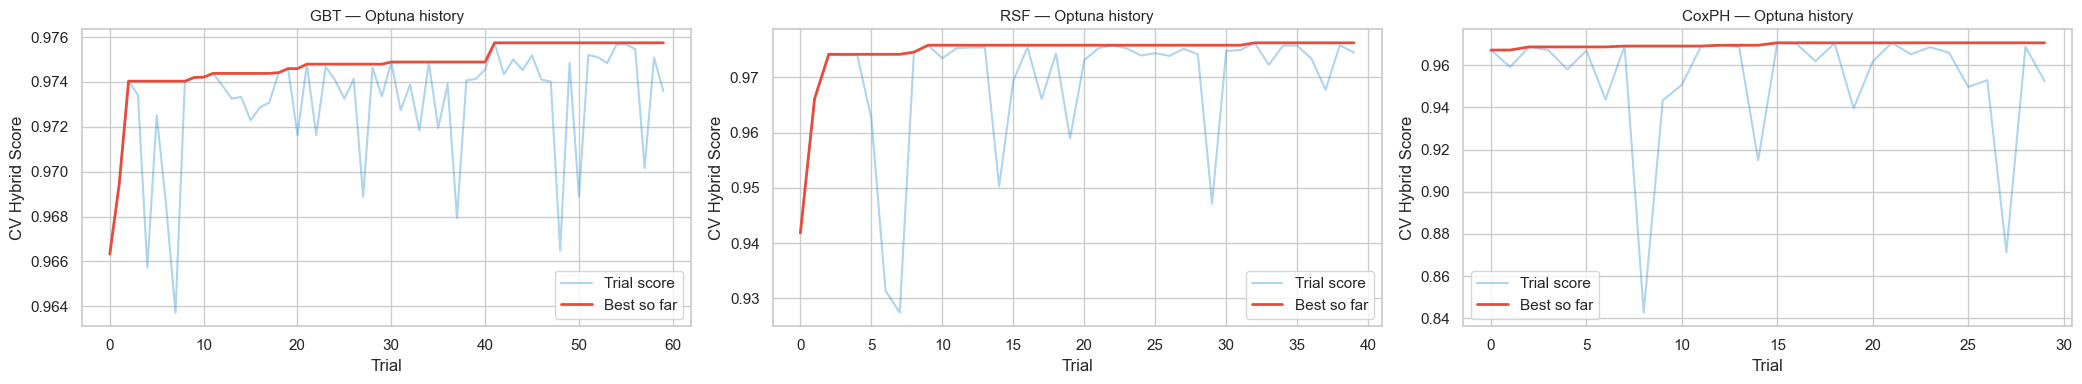

In [11]:
if IMPROVEMENT_CONFIG['run_optuna'] and optuna_studies:
    fig, axes = plt.subplots(1, len(optuna_studies), figsize=(7 * len(optuna_studies), 4))
    if len(optuna_studies) == 1:
        axes = [axes]
    for ax, (name, study) in zip(axes, optuna_studies.items()):
        vals    = [t.value for t in study.trials if t.value is not None]
        running = np.maximum.accumulate(vals)
        ax.plot(vals,   alpha=0.4, color='#3498db', label='Trial score')
        ax.plot(running, color='#e74c3c', linewidth=2, label='Best so far')
        ax.set_title(f'{name} — Optuna history', fontsize=11)
        ax.set_xlabel('Trial')
        ax.set_ylabel('CV Hybrid Score')
        ax.legend()
    plt.tight_layout()
    plt.show()

In [12]:
# ── Score comparison: default vs tuned ──
print('--- Tuned params CV scores ---')
tuned_summary, tuned_cv = run_cv(TUNED_PARAMS, X_train, y_event, y_time,
                                  label_prefix='tuned ')

print('\n=== Default vs Tuned (Hybrid Score) ===')
for name in IMPROVEMENT_CONFIG['enabled_models']:
    base = baseline_summary[name]['Hybrid']
    tuned = tuned_summary[name]['Hybrid']
    delta = tuned - base
    arrow = '↑' if delta > 0 else '↓'
    print(f'  {name:<8}: {base:.5f} → {tuned:.5f}  ({arrow}{abs(delta):.5f})')

--- Tuned params CV scores ---
  tuned GBT     : C-index=0.9483  W-Brier=0.0125  Hybrid=0.9757
  tuned RSF     : C-index=0.9556  W-Brier=0.0149  Hybrid=0.9762
  tuned CoxPH   : C-index=0.9437  W-Brier=0.0178  Hybrid=0.9707

=== Default vs Tuned (Hybrid Score) ===
  GBT     : 0.97224 → 0.97574  (↑0.00350)
  RSF     : 0.96976 → 0.97623  (↑0.00648)
  CoxPH   : 0.96684 → 0.97067  (↑0.00383)


## 5. OOF Collection
Collect out-of-fold predictions from every base model. These are used by both the stacking meta-learner and the isotonic calibrator.

In [13]:
n_train  = len(X_train)
enabled  = IMPROVEMENT_CONFIG['enabled_models']

# Storage: oof_probs[model_name][horizon] = array of shape (n_train,)
oof_probs = {name: {H: np.zeros(n_train) for H in HORIZONS} for name in enabled}

skf_outer = StratifiedKFold(n_splits=IMPROVEMENT_CONFIG['n_outer_folds'],
                             shuffle=True, random_state=SEED)

print('Collecting OOF predictions from tuned base models...')
for fold, (tr, val) in enumerate(skf_outer.split(X_train, y_event), 1):
    for name in enabled:
        m = build_model(name, TUNED_PARAMS[name])
        m.fit(X_train.iloc[tr], y_event[tr], y_time[tr])
        pd_ = m.predict_survival_probs(X_train.iloc[val])
        for H in HORIZONS:
            oof_probs[name][H][val] = pd_[H]
    print(f'  Fold {fold} done.')

print('OOF collection complete.')

  Fold 1 done.
  Fold 2 done.
  Fold 3 done.
  Fold 4 done.
  Fold 5 done.
OOF collection complete.


In [14]:
# ── Baseline ensemble OOF (uniform weights) for comparison ──
w = 1.0 / len(enabled)
ensemble_oof = {H: sum(oof_probs[n][H] for n in enabled) * w for H in HORIZONS}
ensemble_oof = enforce_monotonicity(ensemble_oof)

row_ens = evaluate(y_event, y_time, ensemble_oof, label='Tuned Ensemble (uniform, OOF)')
print('Tuned ensemble OOF scores (uniform weights):')
print(f"  C-index={row_ens['C-index']:.5f}  W-Brier={row_ens['W-Brier']:.5f}  "
      f"Hybrid={row_ens['Hybrid']:.5f}")
print()
print('Note: OOF Brier is evaluated on the same folds the model was trained on for stacking/calibration.')
print('This is slightly optimistic; the CV in Section 3 is the unbiased estimate.')

Tuned ensemble OOF scores (uniform weights):
  C-index=0.94170  W-Brier=0.01439  Hybrid=0.97243

Note: OOF Brier is evaluated on the same folds the model was trained on for stacking/calibration.
This is slightly optimistic; the CV in Section 3 is the unbiased estimate.


## 6. Stacking Meta-Learner

A Ridge regression is trained **per horizon** with inputs `[cox_H, rsf_H, gbt_H]` and target `y_obs_H`.  
Non-negative coefficients are enforced so each model contributes positively.  
The learned weights tell you how much each model is trusted at each time horizon.

In [17]:
class StackingLayer:
    """
    Trains one Ridge regressor per horizon on OOF base-model predictions.
    Inputs:  {model_name: {H: oof_array}}
    Outputs: {H: calibrated_array}
    """
    def __init__(self, alphas=(0.01, 0.1, 1.0, 10.0, 100.0)):
        self.alphas  = alphas
        self.models  = {}   # H -> fitted RidgeCV
        self.weights = {}   # H -> coefficient dict (for inspection)

    def _meta_X(self, probs_by_model, H):
        return np.column_stack([probs_by_model[n][H] for n in enabled])

    def fit(self, oof_probs_by_model, y_event, y_time):
        for H in HORIZONS:
            meta_X = self._meta_X(oof_probs_by_model, H)
            # Exclude fires censored before H (no ground truth available)
            mask   = ~((y_event == 0) & (y_time < H))
            y_obs  = ((y_event == 1) & (y_time <= H)).astype(float)

            from sklearn.linear_model import Ridge
            from sklearn.model_selection import cross_val_score

            best_alpha, best_mse = self.alphas[0], np.inf
            for alpha in self.alphas:
                r      = Ridge(alpha=alpha, positive=True)
                scores = cross_val_score(r, meta_X[mask], y_obs[mask],
                                        cv=5, scoring='neg_mean_squared_error')
                if -scores.mean() < best_mse:
                    best_mse, best_alpha = -scores.mean(), alpha

            ridge = Ridge(alpha=best_alpha, positive=True)
            ridge.fit(meta_X[mask], y_obs[mask])
            
            self.models[H]  = ridge
            self.weights[H] = dict(zip(enabled, ridge.coef_))
        return self

    def predict(self, probs_by_model):
        result = {}
        for H in HORIZONS:
            meta_X    = self._meta_X(probs_by_model, H)
            result[H] = self.models[H].predict(meta_X).clip(0, 1)
        return result


print('StackingLayer class defined.')

StackingLayer class defined.


Stacking meta-learner trained.
Stacked OOF: C-index=0.94145  W-Brier=0.01295  Hybrid=0.97337

Meta-learner weights per horizon (how much each model is trusted):
            GBT     RSF   CoxPH
Horizon                        
12      0.31900 0.47440 0.18430
24      0.66070 0.24630 0.11050
48      0.72950 0.18730 0.13030
72      0.00000 0.00000 0.00000


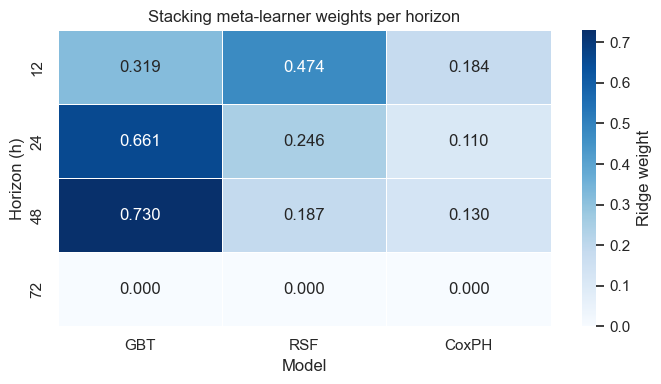

In [18]:
stacker = None
stacked_oof = ensemble_oof.copy()   # fallback to plain ensemble if stacking off

if IMPROVEMENT_CONFIG['run_stacking']:
    stacker = StackingLayer(alphas=IMPROVEMENT_CONFIG['stacking_alpha'])
    stacker.fit(oof_probs, y_event, y_time)

    stacked_oof = stacker.predict(oof_probs)
    stacked_oof = enforce_monotonicity(stacked_oof)

    row_stack = evaluate(y_event, y_time, stacked_oof, label='Stacked (OOF)')
    print('Stacking meta-learner trained.')
    print(f"Stacked OOF: C-index={row_stack['C-index']:.5f}  "
          f"W-Brier={row_stack['W-Brier']:.5f}  Hybrid={row_stack['Hybrid']:.5f}")

    print('\nMeta-learner weights per horizon (how much each model is trusted):')
    weight_df = pd.DataFrame(stacker.weights).T
    weight_df.index.name = 'Horizon'
    print(weight_df.round(4))

    # ── Visual: stacking weights heatmap ──
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(weight_df, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Ridge weight'})
    ax.set_title('Stacking meta-learner weights per horizon', fontsize=12)
    ax.set_xlabel('Model')
    ax.set_ylabel('Horizon (h)')
    plt.tight_layout()
    plt.show()
else:
    print('Stacking skipped.')

## 7. Isotonic Calibration

Isotonic regression maps predicted probabilities to observed event rates in a monotone non-decreasing way. It corrects systematic over/underconfidence without any parametric assumptions.

In [19]:
class IsotonicCalibrator:
    """
    Fits one IsotonicRegression per horizon on (stacked) OOF predictions.
    """
    def __init__(self):
        self.models = {}

    def fit(self, oof_prob_dict, y_event, y_time):
        for H in HORIZONS:
            mask  = ~((y_event == 0) & (y_time < H))
            y_obs = ((y_event == 1) & (y_time <= H)).astype(float)
            iso   = IsotonicRegression(out_of_bounds='clip')
            iso.fit(oof_prob_dict[H][mask], y_obs[mask])
            self.models[H] = iso
        return self

    def predict(self, prob_dict):
        return {H: self.models[H].predict(prob_dict[H]).clip(0, 1)
                for H in HORIZONS}


print('IsotonicCalibrator class defined.')

IsotonicCalibrator class defined.


In [20]:
calibrator  = None
calib_oof   = stacked_oof.copy()

if IMPROVEMENT_CONFIG['run_calibration']:
    calibrator = IsotonicCalibrator()
    calibrator.fit(stacked_oof, y_event, y_time)

    calib_oof = calibrator.predict(stacked_oof)
    calib_oof = enforce_monotonicity(calib_oof)

    row_calib = evaluate(y_event, y_time, calib_oof, label='Calibrated (OOF)')
    print('Isotonic calibration fitted.')
    print(f"Calibrated OOF: C-index={row_calib['C-index']:.5f}  "
          f"W-Brier={row_calib['W-Brier']:.5f}  Hybrid={row_calib['Hybrid']:.5f}")
else:
    print('Calibration skipped.')

Isotonic calibration fitted.
Calibrated OOF: C-index=0.94013  W-Brier=0.01020  Hybrid=0.97490


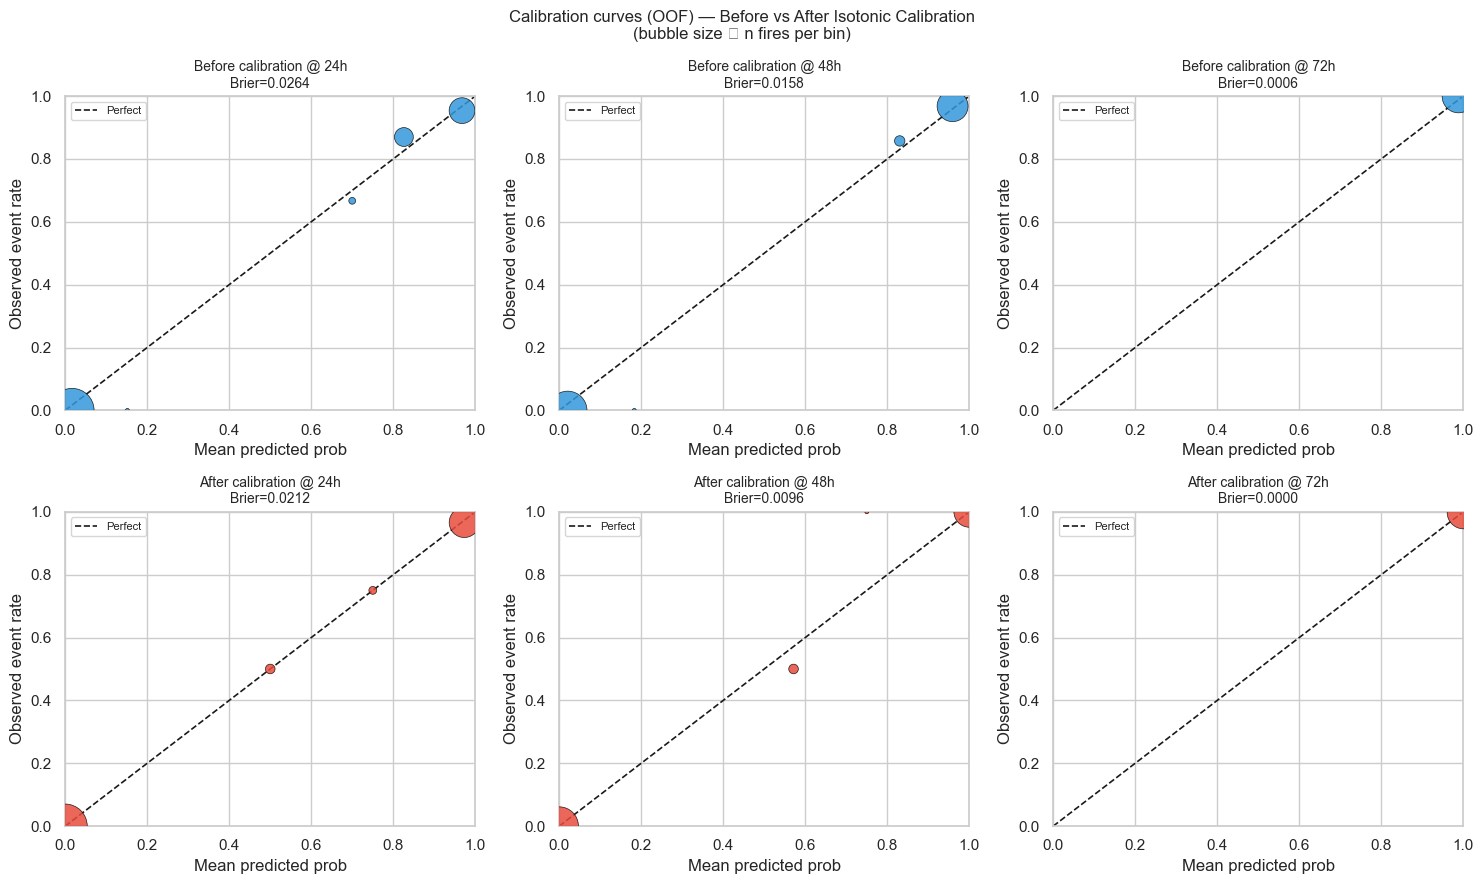

In [21]:
# ── Calibration curves: before vs after ──
def calib_curve(y_event, y_time, probs, H, n_bins=8):
    pred = probs[H]
    obs  = ((y_event == 1) & (y_time <= H)).astype(float)
    mask = ~((y_event == 0) & (y_time < H))
    pred, obs = pred[mask], obs[mask]
    bins   = np.linspace(0, 1, n_bins + 1)
    bid    = np.clip(np.digitize(pred, bins) - 1, 0, n_bins - 1)
    bp, bo, bn = [], [], []
    for b in range(n_bins):
        m = bid == b
        if m.sum() > 0:
            bp.append(pred[m].mean()); bo.append(obs[m].mean()); bn.append(m.sum())
    return np.array(bp), np.array(bo), np.array(bn)

plot_H = [24, 48, 72]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, H in enumerate(plot_H):
    for row, (probs, title, color) in enumerate([
            (ensemble_oof, 'Before calibration', '#3498db'),
            (calib_oof,    'After calibration',  '#e74c3c')]):
        ax = axes[row, col]
        bp, bo, bn = calib_curve(y_event, y_time, probs, H)
        ax.scatter(bp, bo, s=bn * 8, color=color, edgecolors='black',
                   linewidths=0.5, alpha=0.85, zorder=3)
        ax.plot([0,1],[0,1],'k--', linewidth=1.2, label='Perfect')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel('Mean predicted prob')
        ax.set_ylabel('Observed event rate')
        b_val = brier_at_horizon(y_event, y_time, probs[H], H)
        ax.set_title(f'{title} @ {H}h\nBrier={b_val:.4f}', fontsize=10)
        ax.legend(fontsize=8)

plt.suptitle('Calibration curves (OOF) — Before vs After Isotonic Calibration\n'
             '(bubble size ∝ n fires per bin)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Ablation Study — Cumulative Impact of Each Improvement

In [22]:
# Build a clean comparison table showing what each step added
# We use per-model tuned CV scores from Section 4, then OOF-based scores for ensemble/stack/calib.
# Note: the OOF scores for the last 3 rows are slightly optimistic (same data used for fitting).

ablation_rows = []

# 1. Baseline individual models (default params)
for name in enabled:
    ablation_rows.append({
        'Stage': f'{name} (default)',
        **{k: baseline_summary[name][k] for k in ['C-index','W-Brier','Hybrid']}
    })

# 2. Tuned individual models
for name in enabled:
    ablation_rows.append({
        'Stage': f'{name} (tuned)',
        **{k: tuned_summary[name][k] for k in ['C-index','W-Brier','Hybrid']}
    })

# 3. Tuned uniform ensemble (OOF)
r = evaluate(y_event, y_time, ensemble_oof)
ablation_rows.append({'Stage': 'Ensemble uniform (OOF)', **{k: r[k] for k in ['C-index','W-Brier','Hybrid']}})

# 4. + Stacking
if stacker is not None:
    r = evaluate(y_event, y_time, stacked_oof)
    ablation_rows.append({'Stage': '+ Stacking (OOF)', **{k: r[k] for k in ['C-index','W-Brier','Hybrid']}})

# 5. + Calibration
if calibrator is not None:
    r = evaluate(y_event, y_time, calib_oof)
    ablation_rows.append({'Stage': '+ Isotonic calibration (OOF)', **{k: r[k] for k in ['C-index','W-Brier','Hybrid']}})

ablation_df = pd.DataFrame(ablation_rows).set_index('Stage')

def colour_hybrid(s):
    norm = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return [f'background-color: rgba(46,204,113,{v:.2f})' for v in norm]

print('=== ABLATION STUDY ===')
print('(OOF rows are slightly optimistic — use CV rows for unbiased comparison)')
ablation_df.style.apply(colour_hybrid, subset=['Hybrid'])

=== ABLATION STUDY ===
(OOF rows are slightly optimistic — use CV rows for unbiased comparison)


,C-index,W-Brier,Hybrid
Stage,,,
GBT (default),0.945120,0.016132,0.972244
RSF (default),0.945160,0.019703,0.969756
CoxPH (default),0.942485,0.022722,0.966840
GBT (tuned),0.948291,0.012490,0.975744
RSF (tuned),0.955632,0.014939,0.976232
CoxPH (tuned),0.943740,0.017784,0.970673
Ensemble uniform (OOF),0.941703,0.014395,0.972434
+ Stacking (OOF),0.941454,0.012945,0.973375
+ Isotonic calibration (OOF),0.940129,0.010200,0.974899


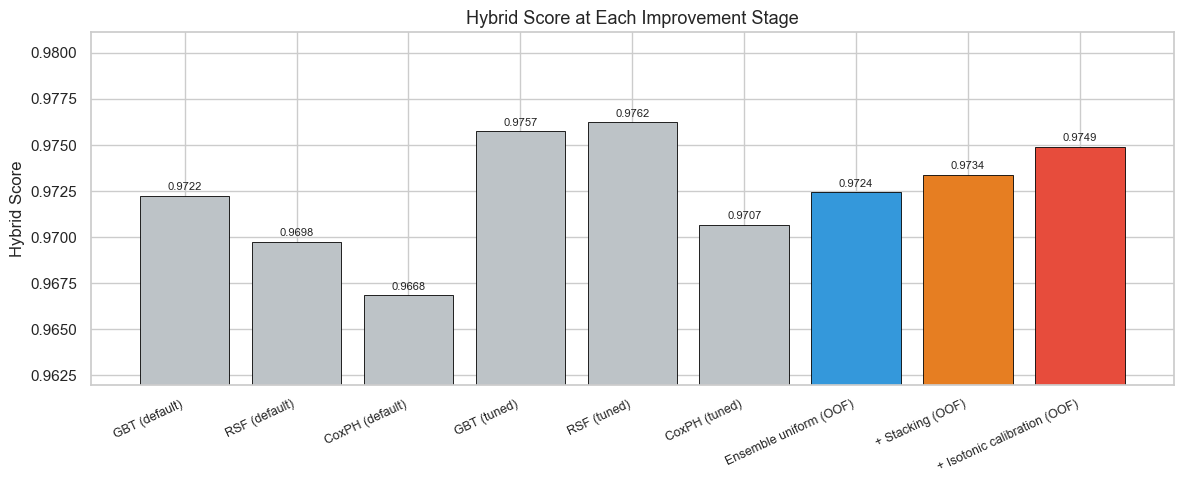

In [23]:
# ── Visual: hybrid score progression ──
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['#bdc3c7'] * (2 * len(enabled)) + ['#3498db', '#e67e22', '#e74c3c']
bars    = ax.bar(ablation_df.index, ablation_df['Hybrid'], color=colors[:len(ablation_df)],
                 edgecolor='black', linewidth=0.6)
ax.set_ylabel('Hybrid Score')
ax.set_title('Hybrid Score at Each Improvement Stage', fontsize=13)
ax.set_ylim(ablation_df['Hybrid'].min() * 0.995, min(1.0, ablation_df['Hybrid'].max() * 1.005))
plt.xticks(rotation=25, ha='right', fontsize=9)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Final Predictions & Submission

In [24]:
# ── Retrain all models on full training set ──
final_models = {}
for name in enabled:
    m = build_model(name, TUNED_PARAMS[name])
    m.fit(X_train, y_event, y_time)
    final_models[name] = m
    print(f'{name}: fitted on full train.')

GBT: fitted on full train.
RSF: fitted on full train.
CoxPH: fitted on full train.


In [25]:
# ── Generate test predictions through the full pipeline ──

# Step 1: Base model predictions on test
test_base_probs = {name: final_models[name].predict_survival_probs(X_test)
                   for name in enabled}

# Step 2: Stacking (if enabled)
if stacker is not None:
    test_probs = stacker.predict(test_base_probs)
else:
    w = 1.0 / len(enabled)
    test_probs = {H: sum(test_base_probs[n][H] for n in enabled) * w for H in HORIZONS}

# Step 3: Isotonic calibration (if enabled)
if calibrator is not None:
    test_probs = calibrator.predict(test_probs)

# Step 4: Enforce monotonicity
test_probs = enforce_monotonicity(test_probs)

# ── Verify ──
for i in range(len(X_test)):
    p = [test_probs[H][i] for H in HORIZONS]
    assert p == sorted(p), f'Monotonicity violated at row {i}'
print('Monotonicity check passed.')

print('\nTest prediction summary:')
for H in HORIZONS:
    print(f'  prob_{H}h: mean={test_probs[H].mean():.4f}  '
          f'min={test_probs[H].min():.4f}  max={test_probs[H].max():.4f}')

Monotonicity check passed.

Test prediction summary:
  prob_12h: mean=0.1898  min=0.0000  max=1.0000
  prob_24h: mean=0.2536  min=0.0000  max=1.0000
  prob_48h: mean=0.2856  min=0.0000  max=1.0000
  prob_72h: mean=1.0000  min=1.0000  max=1.0000


In [26]:
# ── Save submission ──
submission = pd.DataFrame({
    'event_id': test_raw['event_id'].values,
    'prob_12h': test_probs[12],
    'prob_24h': test_probs[24],
    'prob_48h': test_probs[48],
    'prob_72h': test_probs[72],
})

sample = pd.read_csv(DATA_DIR + 'sample_submission.csv')
assert list(submission.columns) == list(sample.columns)
assert set(submission.event_id)  == set(sample.event_id)

submission.to_csv('submission_v2.csv', index=False)
print('submission_v2.csv saved.')
print(submission.head(10))

submission_v2.csv saved.
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602   0.00000   0.00000   0.00000   1.00000
1  13353600   0.61538   0.95000   1.00000   1.00000
2  13942327   0.00000   0.00000   0.00000   1.00000
3  16112781   0.61538   0.95000   1.00000   1.00000
4  17132808   0.00000   0.00000   0.00000   1.00000
5  17445696   0.00000   0.00000   0.00000   1.00000
6  17599982   0.00000   0.00000   0.00000   1.00000
7  18750374   0.38889   0.75000   1.00000   1.00000
8  21365245   0.00000   0.00000   0.00000   1.00000
9  23634840   0.38889   0.75000   1.00000   1.00000


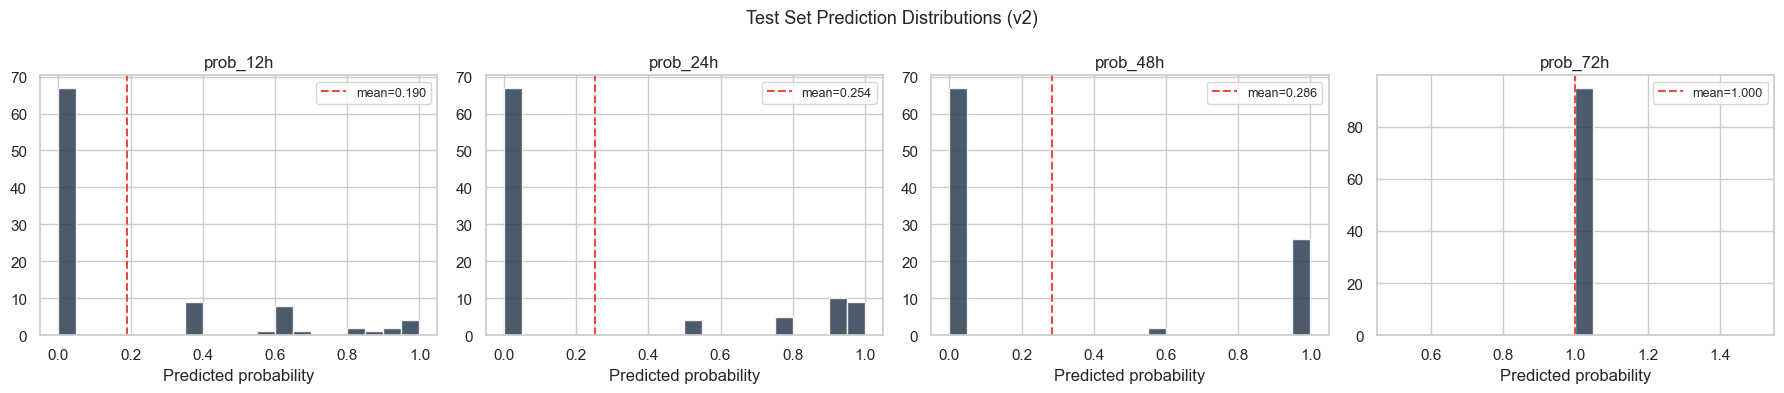

In [27]:
# ── Distribution of test predictions ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, H in zip(axes, HORIZONS):
    ax.hist(test_probs[H], bins=20, color='#2c3e50', edgecolor='white', alpha=0.85)
    ax.axvline(test_probs[H].mean(), color='#e74c3c', ls='--',
               label=f'mean={test_probs[H].mean():.3f}')
    ax.set_title(f'prob_{H}h')
    ax.set_xlabel('Predicted probability')
    ax.legend(fontsize=9)
plt.suptitle('Test Set Prediction Distributions (v2)', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# ── Final summary printout ──
print('=' * 62)
print('  IMPROVEMENT SUMMARY')
print('=' * 62)
print(f"  Enabled models  : {enabled}")
print(f"  Optuna tuning   : {IMPROVEMENT_CONFIG['run_optuna']}")
print(f"  Stacking        : {IMPROVEMENT_CONFIG['run_stacking']}")
print(f"  Calibration     : {IMPROVEMENT_CONFIG['run_calibration']}")
print(f"  Feature count   : {X_train.shape[1]}")
print()
print('  CV scores (unbiased, from Section 4):')
for name in enabled:
    b = baseline_summary[name]['Hybrid']
    t = tuned_summary[name]['Hybrid']
    print(f"    {name:<8} default={b:.5f}  tuned={t:.5f}  gain={t-b:+.5f}")
print()
print('  Pipeline scores (OOF — slightly optimistic):')
for row in ablation_rows[-3:]:
    print(f"    {row['Stage']:<35} Hybrid={row['Hybrid']:.5f}")
print('=' * 62)

  IMPROVEMENT SUMMARY
  Enabled models  : ['GBT', 'RSF', 'CoxPH']
  Optuna tuning   : True
  Stacking        : True
  Calibration     : True
  Feature count   : 27

  CV scores (unbiased, from Section 4):
    GBT      default=0.97224  tuned=0.97574  gain=+0.00350
    RSF      default=0.96976  tuned=0.97623  gain=+0.00648
    CoxPH    default=0.96684  tuned=0.97067  gain=+0.00383

  Pipeline scores (OOF — slightly optimistic):
    Ensemble uniform (OOF)              Hybrid=0.97243
    + Stacking (OOF)                    Hybrid=0.97337
    + Isotonic calibration (OOF)        Hybrid=0.97490
